# **PHẦN 1: EDA**

## **LOAD DATA**

In [ ]:
import os
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
csv_path= "/content/drive/MyDrive/data_vietnamese_dialect.csv"
OUTPUT_DIR = "/content/drive/MyDrive/processed/"
FIGURE_DIR = "/content/drive/MyDrive/figures/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Mount Google Drive thành công")
print(f"CSV: {csv_path}")
print(f"Output: {OUTPUT_DIR}")


Mount Google Drive thành công
CSV: /content/drive/MyDrive/data_vietnamese_dialect.csv
Output: /content/drive/MyDrive/processed/


In [ ]:

df_raw = pd.read_excel(csv_path)
# Kiểm tra kết quả
print(f"\nTên cột: {list(df_raw.columns)}")
print(f"\nMẫu dữ liệu:")
print(df_raw.head(3).to_string())


Tên cột: ['Từ', 'Ý nghĩa', 'Ví dụ tiếng miền Tây', 'Ví dụ tiếng phổ thông', 'Unnamed: 4']

Mẫu dữ liệu:
             Từ                                                                                     Ý nghĩa                                                                                                        Ví dụ tiếng miền Tây                                                                                                       Ví dụ tiếng phổ thông Unnamed: 4
0          À há           (nhẹ giọng) biểu thị sự đồng tình, vui, có ít ngạc nhiên, mang sắc thái thân tỉnh  A há! Mấy đến chơi Hai tiếng reo mừng à há khá đặc biệt khiến chúng tôi ngây ngất Gái ở miền U Minh đâu biết dùng tiếng ấy  A há! Mấy đến chơi Hai tiếng reo mừng à há khá đặc biệt khiến chúng tôi ngây ngất Gái ở miền U Minh đâu biết dùng tiếng ấy        NaN
1          À há                                (nặng giọng) biểu thị sự răn đe, hăm dọa, có sắc thái nghiêm                                                      

In [ ]:
df_raw.drop(['Unnamed: 4'], axis=1, inplace=True)

In [8]:
print("=" * 55)
print("THÔNG TIN TỔNG QUAN")
print("=" * 55)
print(f"Số hàng  : {len(df_raw):,}")
print(f"Số cột   : {df_raw.shape[1]}")
print(f"\nTên cột  : {list(df_raw.columns)}")
print(f"\n{'─'*55}")
print("5 hàng đầu tiên:")
print(df_raw.head())
print(f"\n{'─'*55}")
print("Kiểu dữ liệu:")
print(df_raw.dtypes)
print(f"\n{'─'*55}")
print("Giá trị NULL:")
print(df_raw.isnull().sum())

THÔNG TIN TỔNG QUAN
Số hàng  : 10,869
Số cột   : 4

Tên cột  : ['Từ', 'Ý nghĩa', 'Ví dụ tiếng miền Tây', 'Ví dụ tiếng phổ thông']

───────────────────────────────────────────────────────
5 hàng đầu tiên:
             Từ                                            Ý nghĩa  \
0          À há  (nhẹ giọng) biểu thị sự đồng tình, vui, có ít ...   
1          À há  (nặng giọng) biểu thị sự răn đe, hăm dọa, có s...   
2  A hành a tỏi  ác độc, có ý thức, có tâm tính, muốn làm và là...   
3  A hành a tỏi  mắng nhiếc, có những lời nói nặng, độc ác nhằm...   
4        Á khẩu  ở tình trạng bệnh làm ảnh hưởng tới dây thần k...   

                                Ví dụ tiếng miền Tây  \
0  A há! Mấy đến chơi Hai tiếng reo mừng à há khá...   
1  À há! Riết rồi tụi bây coi tao không ra gì phả...   
2  Ai mà lạ gì con mẹ a hành a tỏi ấy mà mây nói,...   
3   Mới sáng sớm, ngồi đó mà a hành a tỏi ai vậy bà?   
4  Nhưng giọng run rẩy của ông Hai Kiếm vang ra t...   

                               Ví dụ t

## **EDA**

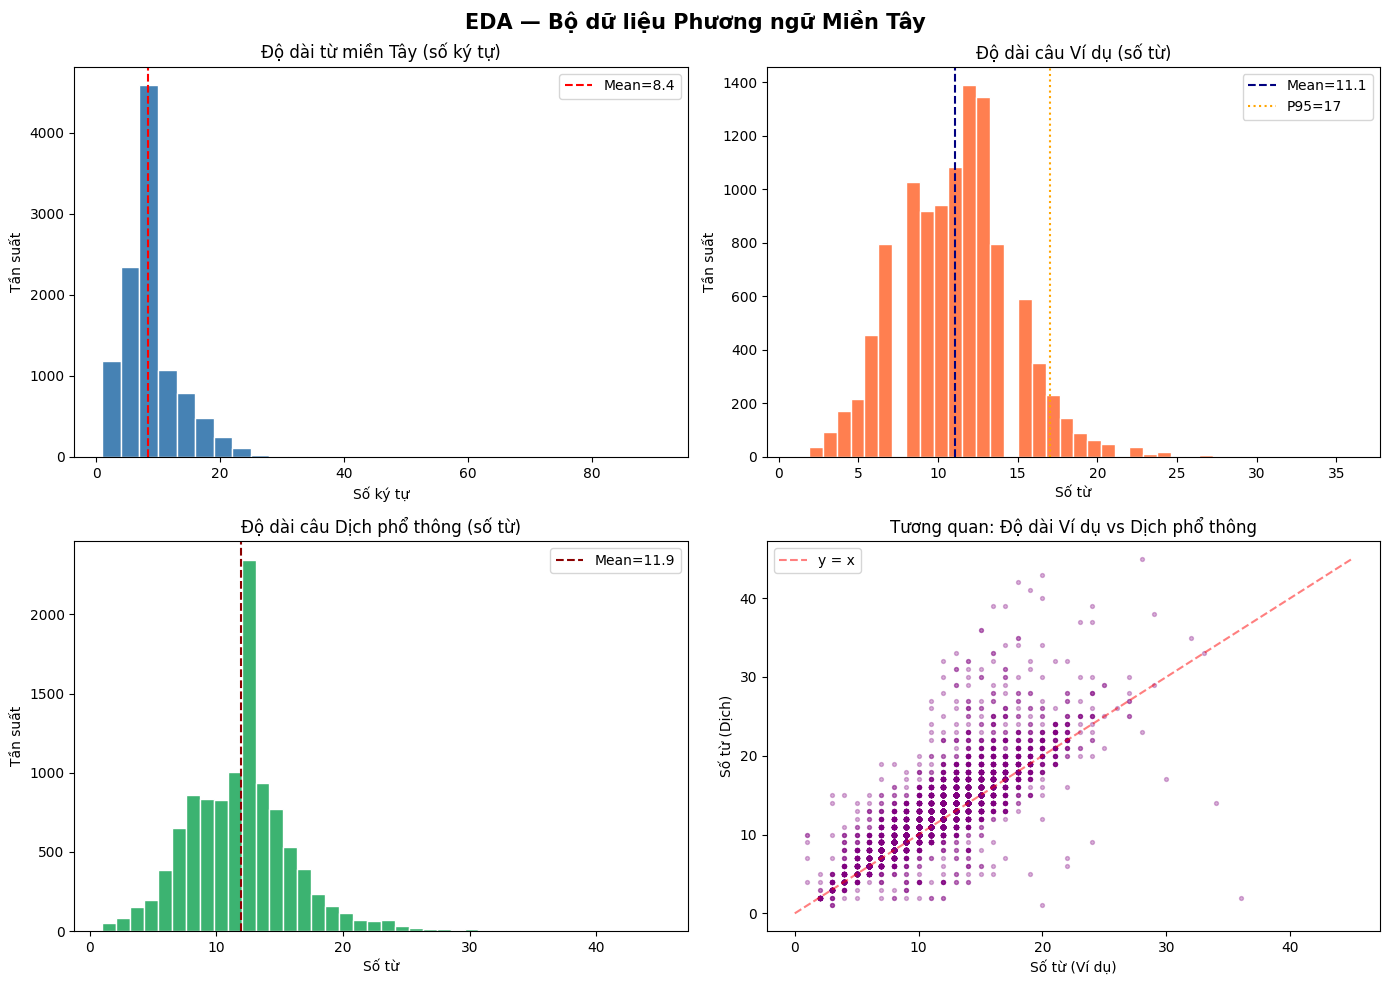

Đã lưu: /content/drive/MyDrive/figures/eda_overview.png

THỐNG KÊ ĐỘ DÀI:
Từ miền Tây     — mean: 8.4 | max: 91
Câu Ví dụ       — mean: 11.1 | P95: 17 | max: 36
Dịch phổ thông  — mean: 11.9 | P95: 19 | max: 45


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA — Bộ dữ liệu Phương ngữ Miền Tây", fontsize=15, fontweight='bold')

# Biểu đồ 1: Phân phối độ dài cột "từ miền tây" (số ký tự)
word_lens = df_raw["Từ"].astype(str).str.len()
axes[0, 0].hist(word_lens, bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title("Độ dài từ miền Tây (số ký tự)")
axes[0, 0].set_xlabel("Số ký tự"); axes[0, 0].set_ylabel("Tần suất")
axes[0, 0].axvline(word_lens.mean(), color='red', linestyle='--',
                   label=f'Mean={word_lens.mean():.1f}')
axes[0, 0].legend()

# Biểu đồ 2: Phân phối độ dài cột "ví dụ" (số từ)
example_lens = df_raw["Ví dụ tiếng miền Tây"].astype(str).str.split().str.len()
axes[0, 1].hist(example_lens, bins=40, color='coral', edgecolor='white')
axes[0, 1].set_title("Độ dài câu Ví dụ (số từ)")
axes[0, 1].set_xlabel("Số từ"); axes[0, 1].set_ylabel("Tần suất")
axes[0, 1].axvline(example_lens.mean(), color='navy', linestyle='--',
                   label=f'Mean={example_lens.mean():.1f}')
axes[0, 1].axvline(example_lens.quantile(0.95), color='orange', linestyle=':',
                   label=f'P95={example_lens.quantile(0.95):.0f}')
axes[0, 1].legend()

# Biểu đồ 3: Phân phối độ dài "dịch phổ thông" (số từ)
target_lens = df_raw["Ví dụ tiếng phổ thông"].astype(str).str.split().str.len()
axes[1, 0].hist(target_lens, bins=40, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title("Độ dài câu Dịch phổ thông (số từ)")
axes[1, 0].set_xlabel("Số từ"); axes[1, 0].set_ylabel("Tần suất")
axes[1, 0].axvline(target_lens.mean(), color='darkred', linestyle='--',
                   label=f'Mean={target_lens.mean():.1f}')
axes[1, 0].legend()

# Biểu đồ 4: So sánh độ dài Input vs Target
axes[1, 1].scatter(example_lens, target_lens, alpha=0.3, s=8, color='purple')
axes[1, 1].set_title("Tương quan: Độ dài Ví dụ vs Dịch phổ thông")
axes[1, 1].set_xlabel("Số từ (Ví dụ)"); axes[1, 1].set_ylabel("Số từ (Dịch)")
# Đường y=x để thấy câu dài/ngắn hơn sau dịch
max_val = max(example_lens.max(), target_lens.max())
axes[1, 1].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='y = x')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}eda_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURE_DIR}eda_overview.png")

# In thống kê số
print("\nTHỐNG KÊ ĐỘ DÀI:")
print(f"Từ miền Tây     — mean: {word_lens.mean():.1f} | max: {word_lens.max()}")
print(f"Câu Ví dụ       — mean: {example_lens.mean():.1f} | P95: {example_lens.quantile(0.95):.0f} | max: {example_lens.max()}")
print(f"Dịch phổ thông  — mean: {target_lens.mean():.1f} | P95: {target_lens.quantile(0.95):.0f} | max: {target_lens.max()}")


In [10]:
def normalize_unicode(text: str) -> str:
    """
    Chuẩn hóa bảng mã Unicode về dạng NFC (chuẩn nhất cho tiếng Việt).
    Sửa lỗi font.
    """
    return unicodedata.normalize('NFC', str(text))

def clean_text(text: str) -> str:
    """
    Làm sạch văn bản tiếng Việt:
    1. Chuẩn hóa Unicode (NFC)
    2. Loại bỏ ký tự điều khiển và ký tự rác
    3. Giữ nguyên dấu câu cơ bản (. , ! ? )
    4. Xóa khoảng trắng thừa
    """
    text = normalize_unicode(text)

    # Loại bỏ ký tự điều khiển (tab, newline bất thường...)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)

    # Chuẩn hóa dấu nháy và dấu gạch ngang về dạng ASCII
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = text.replace('\u2013', '-').replace('\u2014', '-')

    # Giữ lại: chữ cái (kể cả Unicode tiếng Việt), số, dấu câu cơ bản, khoảng trắng
    text = re.sub(r'[^\w\s\.,!?\-\(\)\u00C0-\u024F\u1E00-\u1EFF]', ' ', text)

    # Xóa nhiều khoảng trắng liên tiếp
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def clean_target(text: str) -> str:
    """
    Làm sạch cột Target (dịch phổ thông) — nhẹ tay hơn,chủ yếu chuẩn hóa Unicode và khoảng trắng.
    """
    text = normalize_unicode(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Test hàm làm sạch trước khi áp dụng toàn bộ
test_samples = [
    "đặng  ",          # Khoảng trắng thừa
    "tía\tmá",         # Tab ẩn
    "bển\u2019nè",     # Dấu nháy Unicode
    "xẩm\x0bhay",     # Ký tự điều khiển
]
print("Kiểm tra hàm clean_text:")
for s in test_samples:
    print(f"  Trước: {repr(s)}")
    print(f"  Sau  : {repr(clean_text(s))}")
    print()


Kiểm tra hàm clean_text:
  Trước: 'đặng  '
  Sau  : 'đặng'

  Trước: 'tía\tmá'
  Sau  : 'tía má'

  Trước: 'bển’nè'
  Sau  : 'bển nè'

  Trước: 'xẩm\x0bhay'
  Sau  : 'xẩmhay'



In [11]:
df_clean = df_raw.copy()

# Áp dụng làm sạch từng cột
df_clean["Từ"]   = df_clean["Từ"].apply(clean_text)
df_clean["Ý nghĩa"] = df_clean["Ý nghĩa"].apply(clean_text)
df_clean["Ví dụ tiếng miền Tây"]   = df_clean["Ví dụ tiếng miền Tây"].apply(clean_text)
df_clean["Ví dụ tiếng phổ thông"] = df_clean["Ví dụ tiếng phổ thông"].apply(clean_target)

# Loại bỏ hàng rỗng sau khi làm sạch
before = len(df_clean)
df_clean = df_clean[
    df_clean["Từ"].str.len() > 0
].dropna(subset=["Từ", "Ví dụ tiếng phổ thông"])
after = len(df_clean)

print(f"Đã loại bỏ: {before - after} hàng rỗng/null")
print(f"Còn lại: {after:,} hàng\n")

# Loại bỏ hàng trùng lặp hoàn toàn
before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["Từ", "Ví dụ tiếng phổ thông"])
print(f"Đã loại bỏ: {before_dedup - len(df_clean)} hàng trùng lặp")
print(f"Còn lại sau dedup: {len(df_clean):,} hàng")

# Đổi tên cột
df_clean = df_clean.rename(columns={
    'Từ': 'word',
    'Ý nghĩa': 'meaning',
    'Ví dụ tiếng miền Tây': 'source_sentence',
    'Ví dụ tiếng phổ thông': 'target_sentence'
})

# Xem vài mẫu sau làm sạch và đổi tên
print("\n Mẫu sau làm sạch và đổi tên cột:")
print(df_clean[["word", "meaning", "source_sentence", "target_sentence"]].head(5).to_string(index=False))

Đã loại bỏ: 0 hàng rỗng/null
Còn lại: 10,869 hàng

Đã loại bỏ: 93 hàng trùng lặp
Còn lại sau dedup: 10,776 hàng

 Mẫu sau làm sạch và đổi tên cột:
        word                                                                                                      meaning                                                                                                                            source_sentence                                                                                                                           target_sentence
        À há                            (nhẹ giọng) biểu thị sự đồng tình, vui, có ít ngạc nhiên, mang sắc thái thân tỉnh                 A há! Mấy đến chơi Hai tiếng reo mừng à há khá đặc biệt khiến chúng tôi ngây ngất Gái ở miền U Minh đâu biết dùng tiếng ấy                A há! Mấy đến chơi Hai tiếng reo mừng à há khá đặc biệt khiến chúng tôi ngây ngất Gái ở miền U Minh đâu biết dùng tiếng ấy
        À há                                           

In [21]:
# Token đặc biệt phân tách các trường thông tin
SEP_TOKEN = "[SEP]"

def build_input(row) -> str:
    """
    Ghép 3 cột thành 1 chuỗi input:
    "từ miền tây [SEP] giải thích [SEP] ví dụ"

    Mục đích: cung cấp đủ ngữ cảnh cho mô hình hiểu nghĩa từ
    trước khi sinh ra bản dịch tiếng phổ thông.
    """
    tu    = str(row["word"]).strip()
    giai  = str(row["meaning"]).strip()
    vd    = str(row["source_sentence"]).strip()
    return f"{tu} {SEP_TOKEN} {giai} {SEP_TOKEN} {vd}"


df_clean['input_text']  = df_clean.apply(build_input, axis=1)
df_clean['target_text'] = df_clean["target_sentence"].str.strip()


print("=" * 65)
print(" MẪU INPUT → TARGET (sau khi ghép)")
print("=" * 65)
for i, row in df_clean.head(5).iterrows():
    print(f"\nINPUT  : {row['input_text']}")
    print(f"TARGET : {row['target_text']}")
    print("─" * 65)

# Thống kê độ dài input, output sau khi ghép
input_lens = df_clean['input_text'].str.split().str.len()
print(f"\nĐộ dài INPUT sau ghép (số từ):")
print(f"   Mean: {input_lens.mean():.1f}")
print(f"   P50 : {input_lens.quantile(0.5):.0f}")
print(f"   P95 : {input_lens.quantile(0.95):.0f}")
print(f"   Max : {input_lens.max()}")
print(f" --> chuyển MAX_LEN trong config.py: {int(input_lens.max()) + 100} hoặc {int(input_lens.max())}")


output_lens = df_clean['target_text'].str.split().str.len()
print(f"\nĐộ dài ouput sau ghép (số từ):")
print(f"   Mean: {output_lens.mean():.1f}")
print(f"   P50 : {output_lens.quantile(0.5):.0f}")
print(f"   P95 : {output_lens.quantile(0.95):.0f}")
print(f"   Max : {output_lens.max()}")
print(f" --> chuyển MAX_LEN trong config.py: {int(output_lens.max()) + 100} hoặc {int(output_lens.max())}")

 MẪU INPUT → TARGET (sau khi ghép)

INPUT  : À há [SEP] (nhẹ giọng) biểu thị sự đồng tình, vui, có ít ngạc nhiên, mang sắc thái thân tỉnh [SEP] A há! Mấy đến chơi Hai tiếng reo mừng à há khá đặc biệt khiến chúng tôi ngây ngất Gái ở miền U Minh đâu biết dùng tiếng ấy
TARGET : A há! Mấy đến chơi Hai tiếng reo mừng à há khá đặc biệt khiến chúng tôi ngây ngất Gái ở miền U Minh đâu biết dùng tiếng ấy
─────────────────────────────────────────────────────────────────

INPUT  : À há [SEP] (nặng giọng) biểu thị sự răn đe, hăm dọa, có sắc thái nghiêm [SEP] À há! Riết rồi tụi bây coi tao không ra gì phải hôn?
TARGET : À há! Riết rồi bọn cậu coi tớ không ra gì phải không?
─────────────────────────────────────────────────────────────────

INPUT  : A hành a tỏi [SEP] ác độc, có ý thức, có tâm tính, muốn làm và làm những hành động gây tai hại cho người khác [SEP] Ai mà lạ gì con mẹ a hành a tỏi ấy mà mây nói, con con mẻ, mẻ còn đày nói chi con ở
TARGET : Hắn là một tay giang hồ có thế lực
───────────

In [18]:
df_clean.to_csv(os.path.join(OUTPUT_DIR, 'processed_data.csv'), index=False)
print(f"Đã lưu file processed_data.csv tại {OUTPUT_DIR}processed_data.csv")

Đã lưu file processed_data.csv tại /content/drive/MyDrive/processed/processed_data.csv


In [19]:
df_input_output = df_clean[['input_text', 'target_text']]
df_input_output.to_csv(os.path.join(OUTPUT_DIR, 'input_output_data.csv'), index=False)
print(f"Đã lưu file input_output_data.csv tại {OUTPUT_DIR}input_output_data.csv")

Đã lưu file input_output_data.csv tại /content/drive/MyDrive/processed/input_output_data.csv
